In [32]:
#Mengambil isi halaman web (HTML)
import requests

url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [33]:
#Mengubah HTML menjadi obejek yang bisa dibaca Python.
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text,"html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [40]:
#Mengambil semua quote, author, dan tags.
products= soup.find_all("article",class_="product_pod")
print(len(products))

20


In [43]:
#Membaca setiap produk satu per satu
import pandas as pd

data = []

for product in products:

    title = product.h3.a['title']
    price = product.find("p", class_="price_color").text
    rating = product.find("p", class_="star-rating")["class"][1]

    data.append({
        "Title": title,
        "Price": price,
        "Rating": rating
    })

display(pd.DataFrame(data).head())

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [44]:
#Membuat DF
df = pd.DataFrame(data)

print(df.head())

                                   Title    Price Rating
0                   A Light in the Attic  Â£51.77  Three
1                     Tipping the Velvet  Â£53.74    One
2                             Soumission  Â£50.10    One
3                          Sharp Objects  Â£47.82   Four
4  Sapiens: A Brief History of Humankind  Â£54.23   Five


In [46]:
  #SImpan DF
df.to_csv("Books Product.csv", index=False)

print (df)

                                                Title    Price Rating
0                                A Light in the Attic  Â£51.77  Three
1                                  Tipping the Velvet  Â£53.74    One
2                                          Soumission  Â£50.10    One
3                                       Sharp Objects  Â£47.82   Four
4               Sapiens: A Brief History of Humankind  Â£54.23   Five
5                                     The Requiem Red  Â£22.65    One
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34   Four
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93  Three
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60   Four
9                                     The Black Maria  Â£52.15    One
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99    Two
11                              Shakespeare's Sonnets  Â£20.66   Four
12                                        Set Me Free  Â£17.46   Five
13  Scott Pilgrim's 

EDA

In [50]:
#Baca Data
df = pd.read_csv("Books Product.csv")
print(df.head)

<bound method NDFrame.head of                                                 Title    Price Rating
0                                A Light in the Attic  Â£51.77  Three
1                                  Tipping the Velvet  Â£53.74    One
2                                          Soumission  Â£50.10    One
3                                       Sharp Objects  Â£47.82   Four
4               Sapiens: A Brief History of Humankind  Â£54.23   Five
5                                     The Requiem Red  Â£22.65    One
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34   Four
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93  Three
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60   Four
9                                     The Black Maria  Â£52.15    One
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99    Two
11                              Shakespeare's Sonnets  Â£20.66   Four
12                                        Set Me Free  Â£17.

In [51]:
#Informasi data
df.shape    #(baris, kolom)
df.info()   #tipe data & jumlah non null tiap kolom
df.dtypes   #tipe data tiap kolom
df.head()   #5 baris pertama
df.tail(3)  #3 baris terakhir
df.columns  #daftar nama kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   20 non-null     object
 1   Price   20 non-null     object
 2   Rating  20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes


Index(['Title', 'Price', 'Rating'], dtype='object')

In [52]:
#Statistik dasar
df.describe(include="object")

,Title,Price,Rating
count,20,20,20
unique,20,20,5
top,A Light in the Attic,Â£51.77,One
freq,1,1,6


In [53]:
#Mengecek Missing Value
df.isnull().sum()

,0
Title,0
Price,0
Rating,0


In [58]:
#Mengetahui rating yang paling sering muncul
df["Rating"].value_counts()

,count
Rating,
One,6
Five,4
Four,4
Three,3
Two,3


<Axes: xlabel='count', ylabel='Rating'>

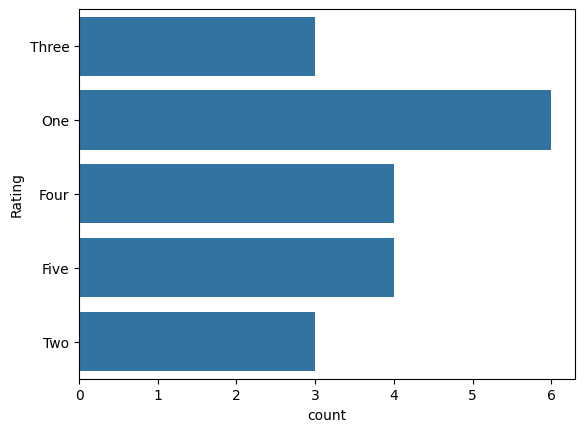

In [59]:
#Visualisasi Data
import seaborn as sns

sns.countplot (data=df, y="Rating")